In [2]:
from hybrid_stereo_method.infrastructure.visualization import display_image
from hybrid_stereo_method.infrastructure.io.image_io import read_fni_to_image_array
import matplotlib.pyplot as plt
import numpy as np

minimum X: -0.9883810877799988, maximum X: 0.9928514361381531
minimum Y: -0.9830315113067627, maximum Y: 0.9837300181388855
minimum Z: -0.11517807841300964, maximum Z: 1.0


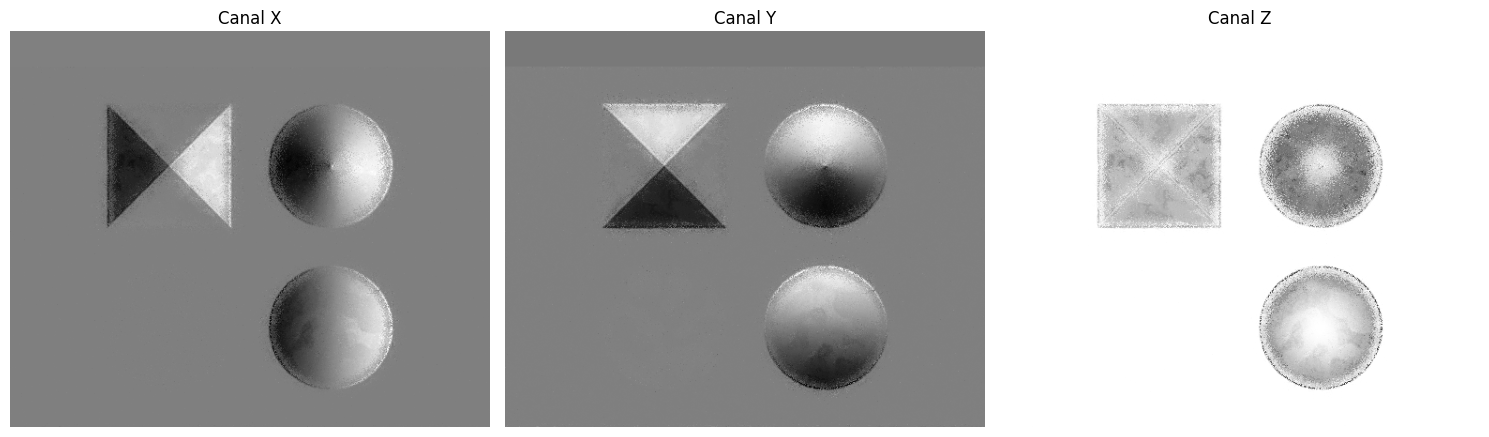

In [3]:
normal_map = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20250422_1747_2025-03-08-stQ-melon24-amb0.00-glo0.50/photometric_stereo/normal_map_with_residuals.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, channel in enumerate(['X', 'Y', 'Z']):
    print(f'minimum {channel}: {np.min(normal_map[:, :, idx])}, maximum {channel}: {np.max(normal_map[:, :, idx])}')
    axes[idx].imshow(normal_map[:, :, idx], cmap='gray')
    axes[idx].set_title(f"Canal {channel}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
normal_map.shape

(422, 512, 4)

In [5]:
def normal_map_to_gradient_map(normal_map):
    """
    Converte um mapa de normais em um mapa de gradientes.
    
    Parâmetros:
        normal_map (numpy.ndarray): Mapa de normais (altura x largura x 3).
        
    Retorna:
        numpy.ndarray: Mapa de gradientes (altura x largura x 2), onde:
                       - gradiente[:, :, 0] representa dz/dx
                       - gradiente[:, :, 1] representa dz/dy
    """
    # Evitar divisão por zero no componente Z
    z_component = normal_map[:, :, 2]
    z_component[z_component == 0] = 1e-10  # Substituir zeros por um valor pequeno

    # Calcular os gradientes
    dz_dx = normal_map[:, :, 0] / z_component
    dz_dy = normal_map[:, :, 1] / z_component

    # Combinar os gradientes em um único array
    gradient_map = np.stack((dz_dx, dz_dy), axis=2)
    return gradient_map


Mapa de gradientes calculado com sucesso.


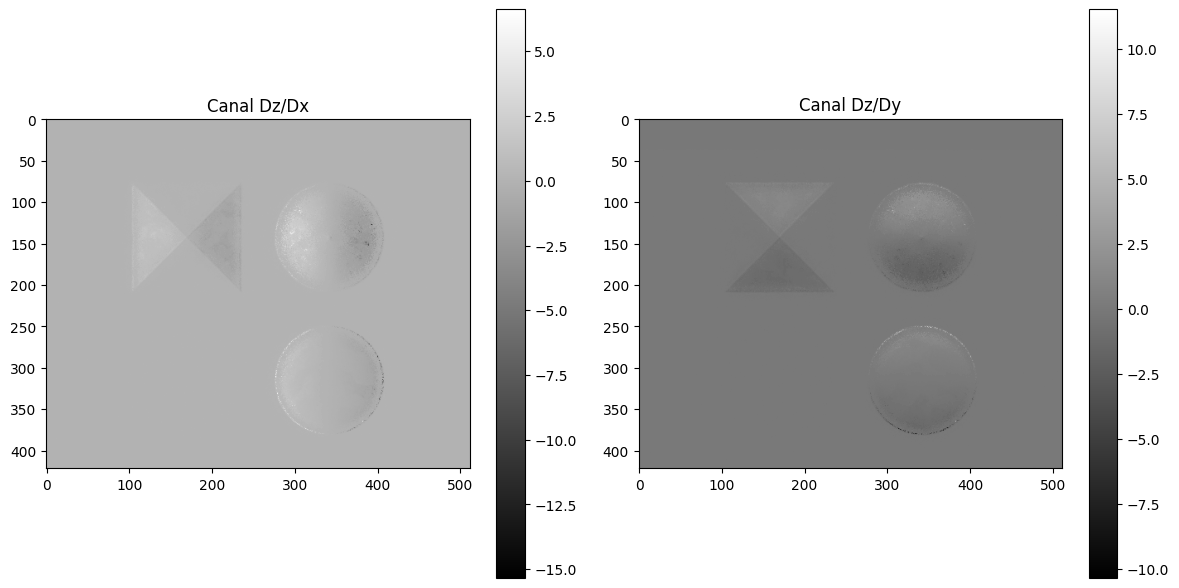

In [8]:
# Exemplo de uso

#normal_map_clean = np.clip(normal_map, np.percentile(normal_map, 2), np.percentile(normal_map, 80))

gradient_map = normal_map_to_gradient_map(normal_map)
print("Mapa de gradientes calculado com sucesso.")


#gradient_map = np.clip(gradient_map, np.percentile(gradient_map, 1), np.percentile(gradient_map, 99)) 

gradient_map[:,:,0] = -gradient_map[:,:,0] # Inverter o sinal do gradiente em y

# Plot the two images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for idx, channel in enumerate(['Dz/Dx', 'Dz/Dy']):
    axes[idx].imshow(gradient_map[:, :, idx], cmap='gray')
    axes[idx].set_title(f"Canal {channel}")
    #axes[idx].axis('off')
    axes[idx].colorbar = plt.colorbar(axes[idx].imshow(gradient_map[:, :, idx], cmap='gray'), ax=axes[idx])



plt.tight_layout()
plt.show()

In [9]:
from hybrid_stereo_method.infrastructure.io.image_io import convert_image_array_to_fni

confidence_extra_exp = np.expand_dims(normal_map[:,:,3], axis=-1)
gradient_map_with_confidence = np.concatenate((gradient_map, confidence_extra_exp), axis=-1)

convert_image_array_to_fni(gradient_map_with_confidence, 'gradiente_recursive.fni')

./gus_integrate_recursive  -initial zero 10  -outPrefix teste_7/teste  -slopes /home/lelis/Documents/Projetos/hybrid-stereo-method/notebooks/multifocus_stereo/gradiente_recursive.fni


In [10]:
image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste-00-beg-G.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem

image[:,:,0] = -image[:,:,0]
#image[:,:,1] = -image[:,:,1] 


image = np.clip(image, np.percentile(image, 1), np.percentile(image, 90)) 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, channel in enumerate(['Dz/Dx', 'Dz/Dy', 'conf']):
    axes[idx].imshow(image[:, :, idx], cmap='gray')
    axes[idx].set_title(f"Canal {channel}")
    axes[idx].colorbar = plt.colorbar(axes[idx].imshow(image[:, :, idx], cmap='gray'), ax=axes[idx])
    #axes[idx].axis('off')

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste-00-beg-G.fni'

In [ ]:
from hybrid_stereo_method.infrastructure.io.image_io import convert_image_array_to_fni

convert_image_array_to_fni(image, 'gradiente_recursive.fni')

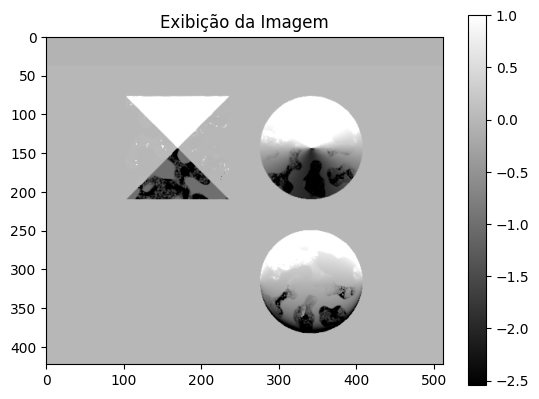

In [ ]:
image = read_fni_to_image_array('gradiente_recursive.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
#image = np.clip(image, np.percentile(image, 5), np.percentile(image, 90))  # Clip values to be in the range [0, 1]
plt.imshow(image[:,:,1], cmap='gray')
plt.colorbar()
plt.title("Exibição da Imagem")
plt.show()

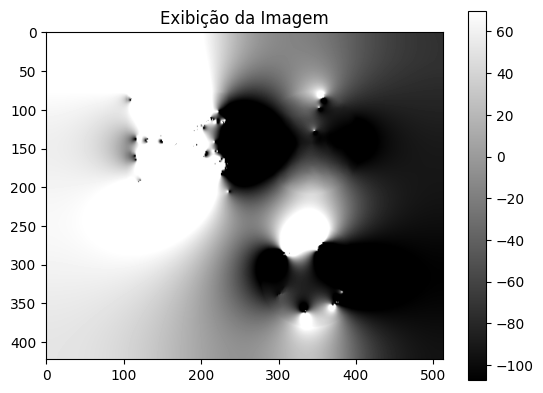

In [ ]:
image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste-00-end-Z.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
image = np.clip(image, np.percentile(image, 5), np.percentile(image, 90))  # Clip values to be in the range [0, 1]
plt.imshow(image[:,:,0], cmap='gray')
plt.colorbar()
plt.title("Exibição da Imagem")
plt.show()

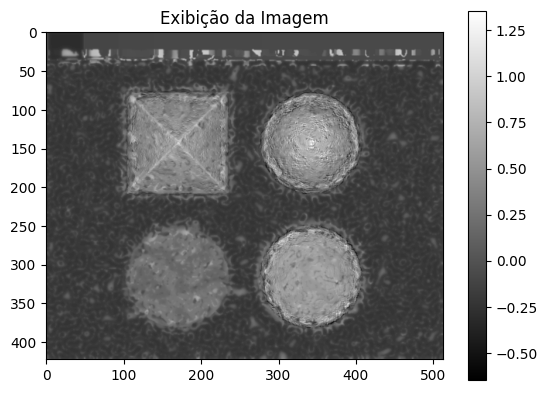

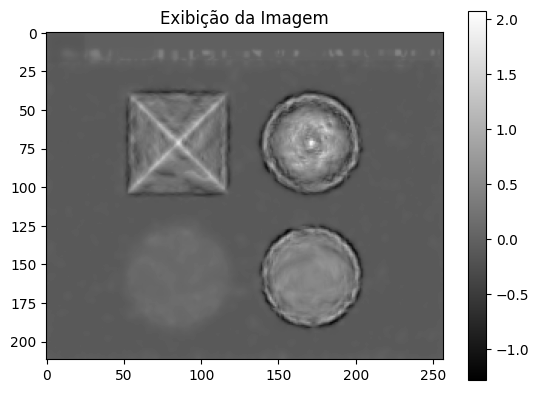

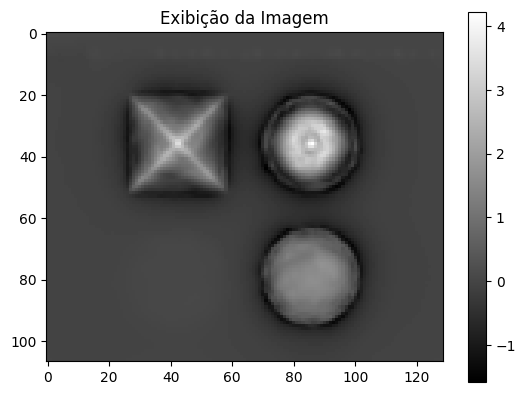

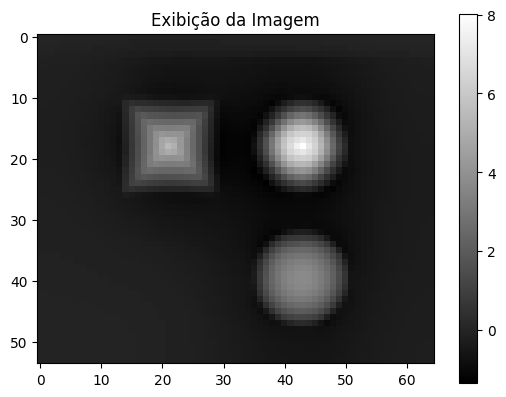

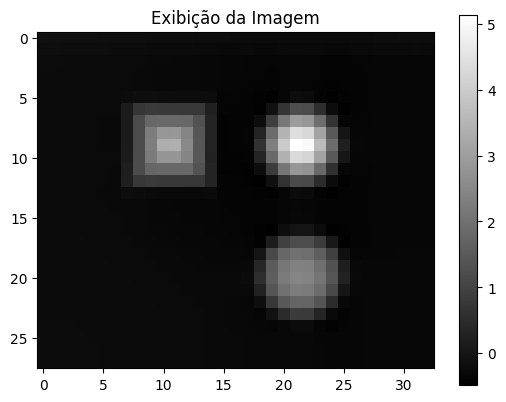

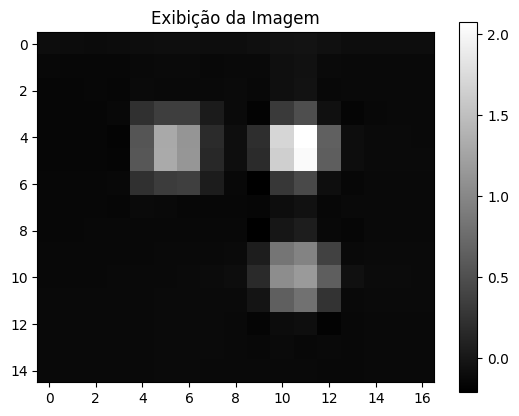

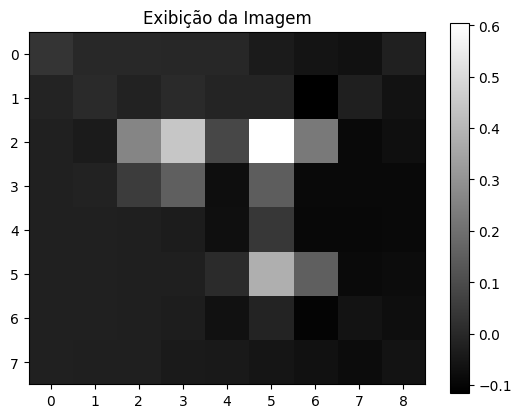

In [18]:
for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste_9/teste-0{i}-end-Z.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem
    plt.imshow(image[:,:,0], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

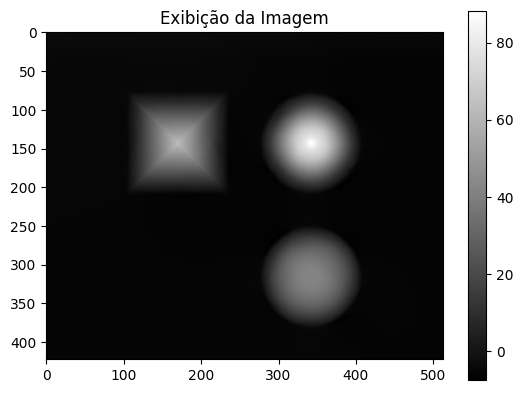

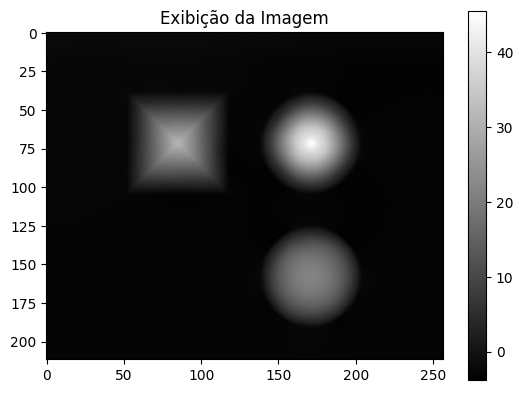

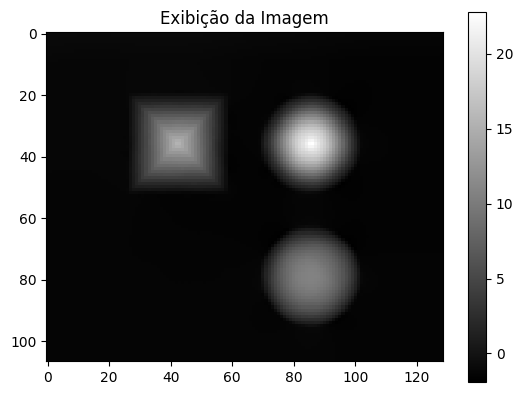

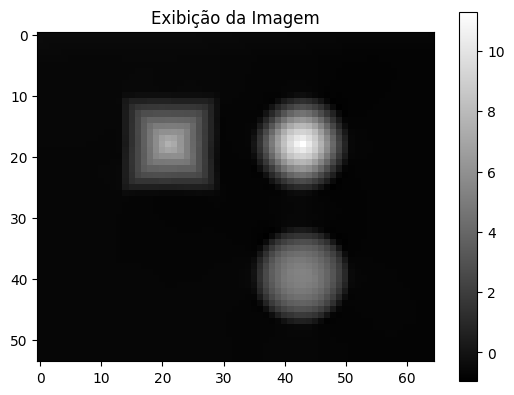

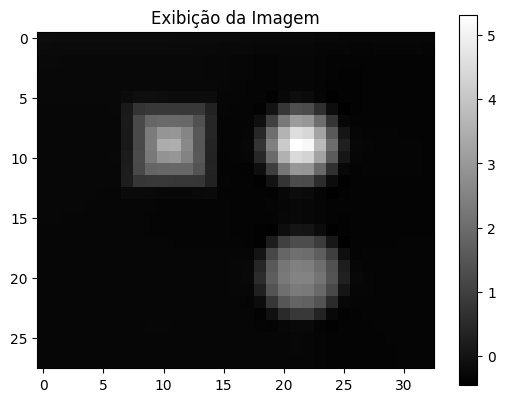

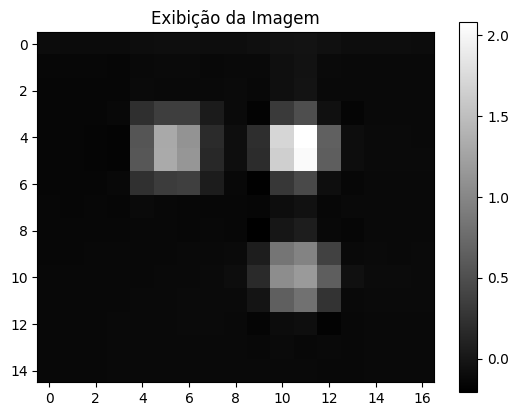

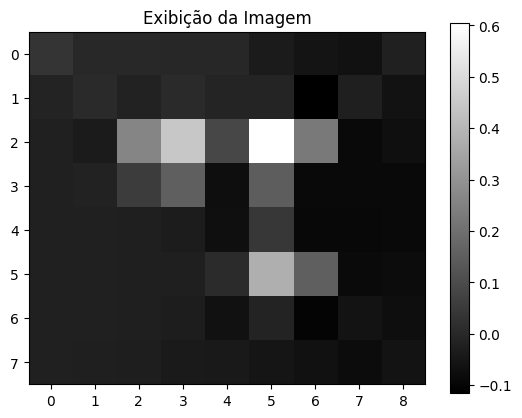

In [19]:
for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste_10/teste-0{i}-end-Z.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem
    plt.imshow(image[:,:,0], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

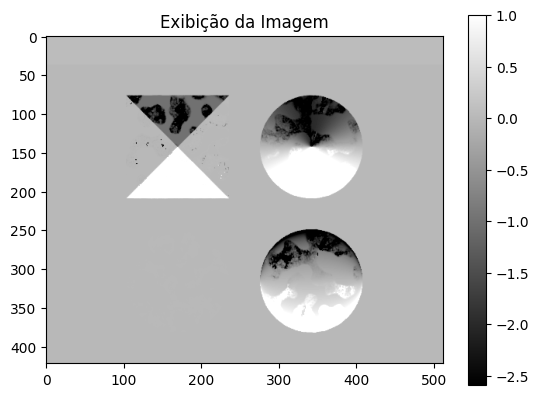

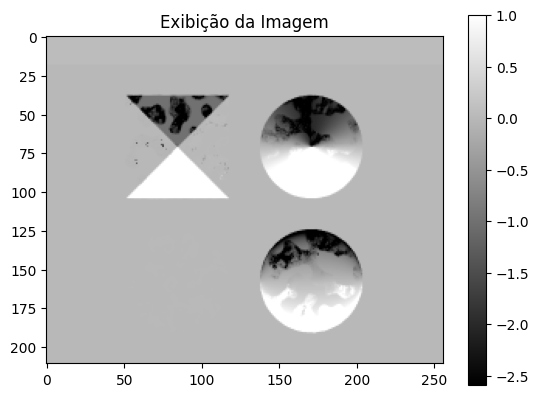

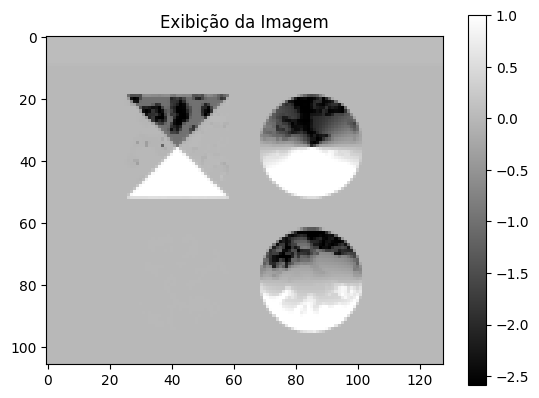

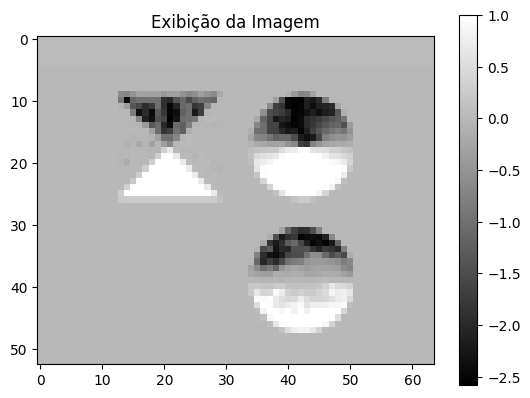

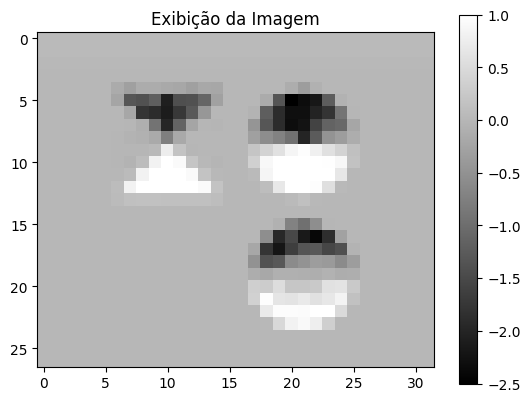

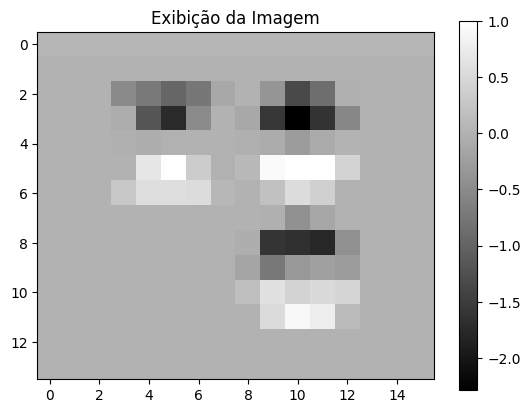

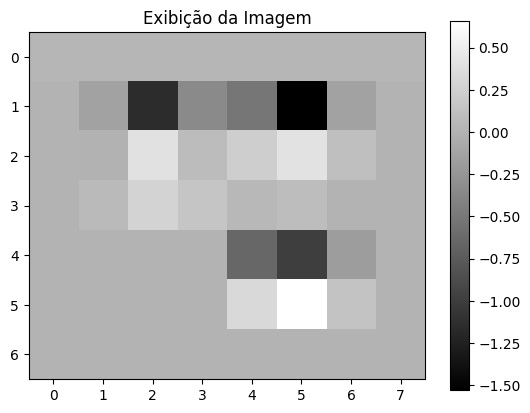

In [ ]:
import numpy as np

for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste_3/teste-0{i}-beg-G.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem



    plt.imshow(image[:,:,1], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

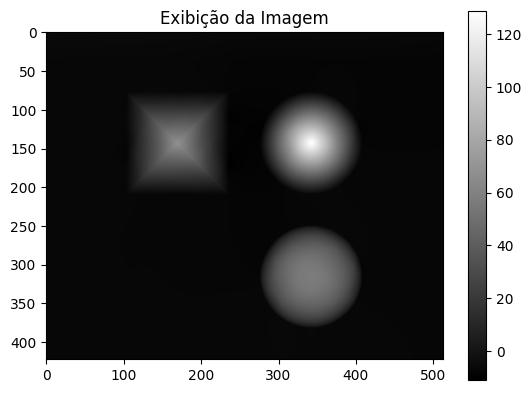

In [ ]:
image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste_7/teste-00-end-Z.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
#image = np.clip(image, np.percentile(image, 2), np.percentile(image, 80))  # Clip values to be in the range [0, 1]
#image = np.clip(image,0.0, 1.2)
plt.imshow(image[:,:,0], cmap='gray')
plt.colorbar()
plt.title("Exibição da Imagem")
plt.show()

In [ ]:
np.percentile(image, 90)

np.float32(22503.469)

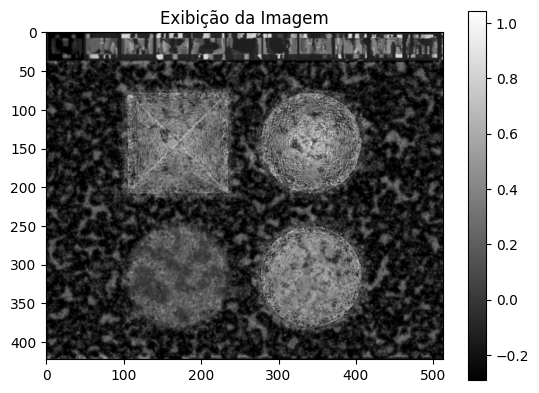

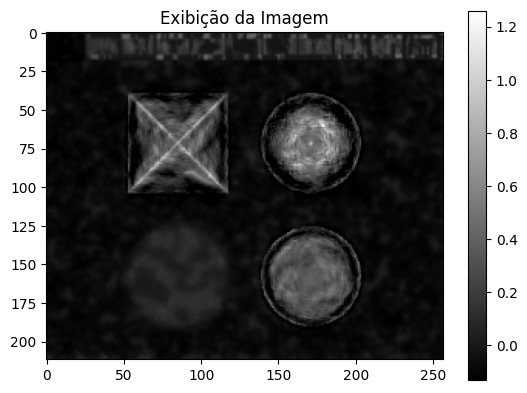

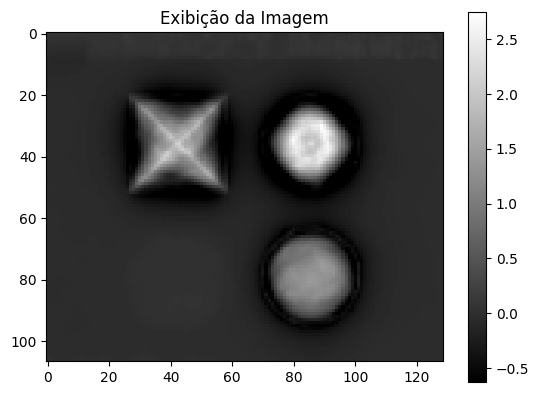

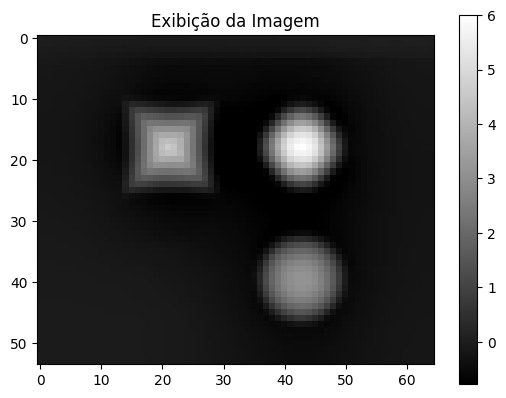

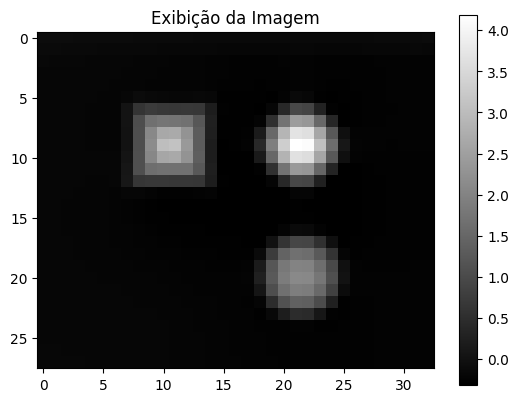

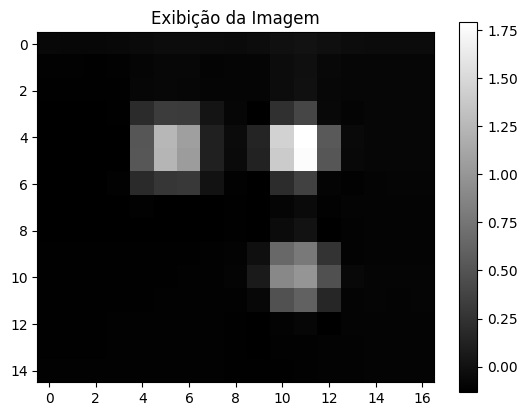

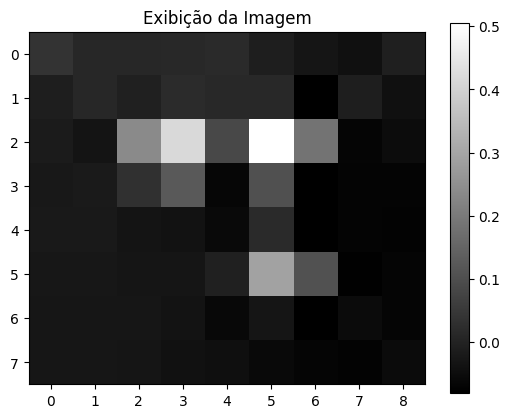

In [44]:
for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20250422_1716_2025-03-08-stQ-melon24-amb0.00-glo0.50/integration/teste-0{i}-end-Z.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem
    image = np.clip(image, np.percentile(image, 2), np.percentile(image, 95))  # Clip values to be in the range [0, 1]
    plt.imshow(image[:,:,0], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

In [37]:
import subprocess

# Defina o comando e os argumentos
command = [
    "/home/lelis/Documents/Projetos/hybrid-stereo-method/csrc/integrate_recursive/gus_integrate_recursive",
    "-initial", "zero", "10",
    "-outPrefix", "/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20250422_1801_2025-03-08-stQ-melon24-amb0.00-glo0.50/integration/teste",
    "-slopes", "/home/lelis/Documents/Projetos/hybrid-stereo-method/notebooks/hybrid_method/gradiente_recursive.fni",
    "-hints", "/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20250422_1801_2025-03-08-stQ-melon24-amb0.00-glo0.50/multifocus_stereo/average/zMos_with_confidence.fni",
    "1"
]

# Execute o comando
try:
    result = subprocess.run(command, check=True, text=True, capture_output=True)
    print("Saída do comando:", result.stdout)
except subprocess.CalledProcessError as e:
    print("Erro ao executar o comando:", e.stderr)

Saída do comando: 


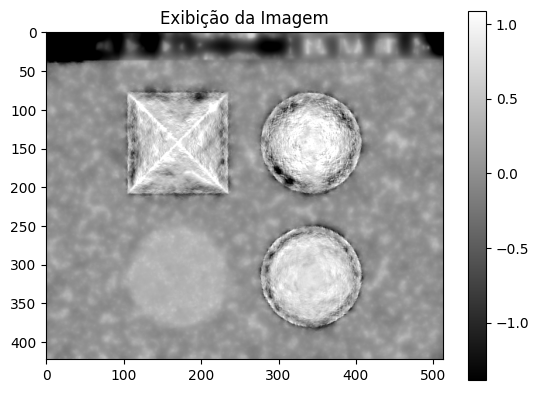

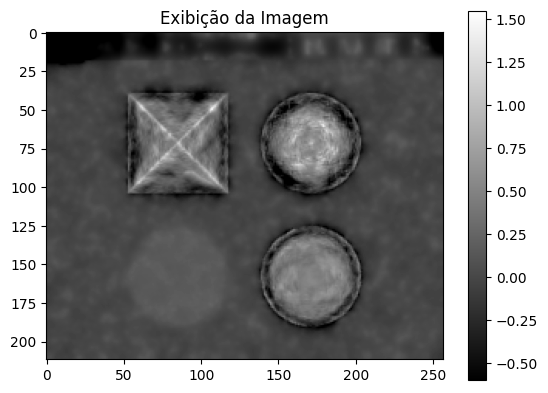

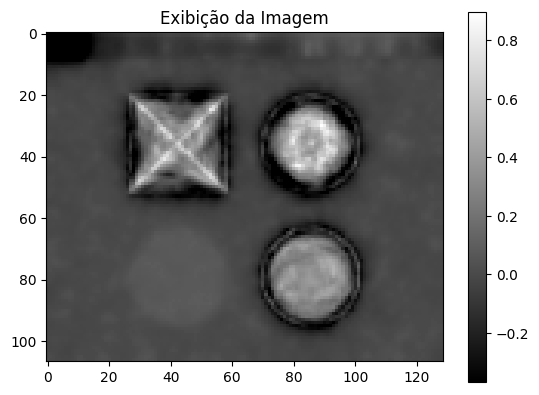

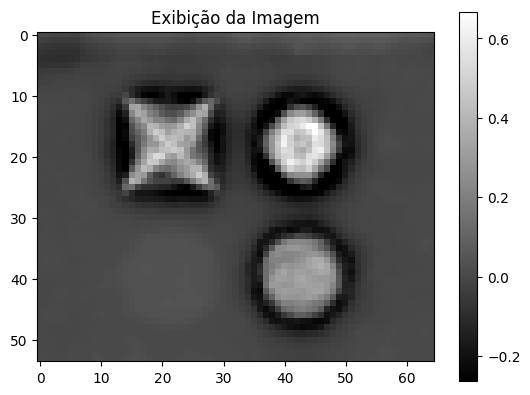

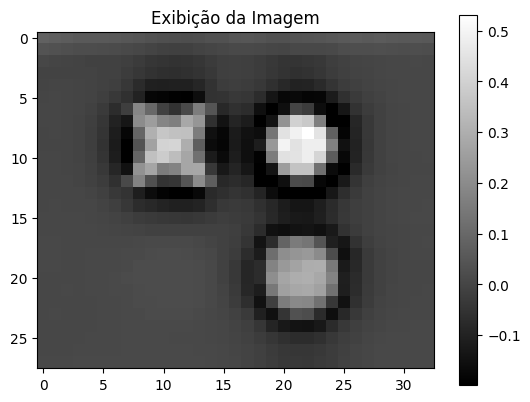

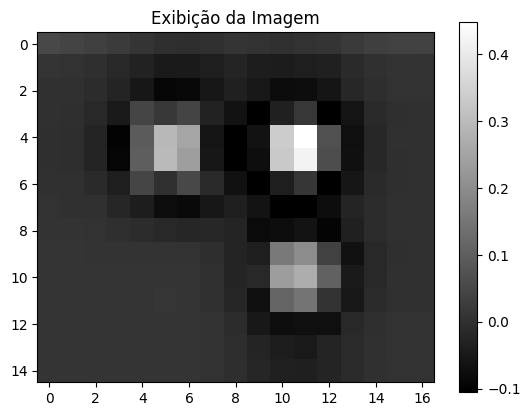

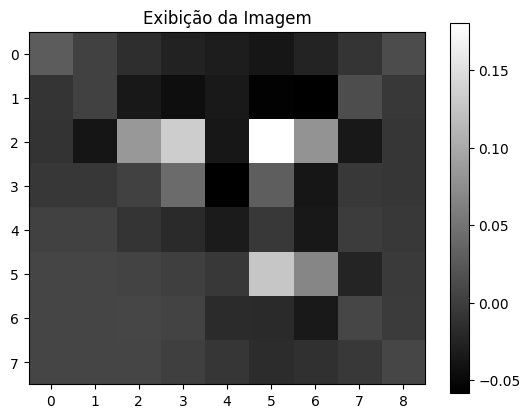

In [48]:
for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20250422_1801_2025-03-08-stQ-melon24-amb0.00-glo0.50/integration/teste-0{i}-end-Z.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem
    image = np.clip(image, np.percentile(image, 1), np.percentile(image, 99))  # Clip values to be in the range [0, 1]
    plt.imshow(image[:,:,0], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()